# Project 11 - Reward Engineering

Project 09의 Q-Learning 구조는 유지하고, Reward만 A/B/C/D로 바꿔 비교한다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
class CarEnv:
    def __init__(self, reward_type="A"):
        self.m = 1000.0
        self.dt = 0.1
        self.force_scale = 1000.0
        self.target = 10.0
        self.reward_type = reward_type

        self.x = 0.0
        self.v = 0.0
        self.previous_distance = 0.0
        self.current_distance = 0.0
        self.error = self.target - self.x

    def reset(self):
        self.x = 0.0
        self.v = 0.0
        self.previous_distance = abs(self.target - self.x)
        self.current_distance = abs(self.target - self.x)
        self.error = self.target - self.x
        return np.array([self.x, self.v])

    def step(self, action):
        self.previous_distance = abs(self.target - self.x)

        F = action * self.force_scale
        a = F / self.m

        self.v = self.v + a * self.dt
        self.x = self.x + self.v * self.dt
        self.error = self.target - self.x
        self.current_distance = abs(self.target - self.x)

        next_state = np.array([self.x, self.v])
        done = self.x >= self.target

        reward = self.calculate_reward(
            self.previous_distance,
            self.current_distance,
            done
        )

        return next_state, reward, done

    def calculate_reward(self, prev_distance, new_distance, done):
        if self.reward_type == "A":
            reward = -new_distance

        elif self.reward_type == "B":
            if new_distance < prev_distance:
                reward = 1
            else:
                reward = -1

        elif self.reward_type == "C":
            if done:
                reward = 100
            else:
                reward = -1

        elif self.reward_type == "D":
            reward = -new_distance

            if new_distance < prev_distance:
                reward += 1
            elif new_distance > prev_distance:
                reward -= 1

            if done:
                reward += 100

        else:
            raise ValueError("reward_type must be one of: A, B, C, D")

        return reward

In [3]:
actions = [-1, 0, 1]

def discretize_state(state):
    x_bin = int(state[0])
    v_bin = int(state[1])
    return (x_bin, v_bin)

def get_q_values(Q, state):
    if state not in Q:
        Q[state] = [0.0, 0.0, 0.0]
    return Q[state]

def select_action(Q, state, epsilon):
    if random.random() < epsilon:
        action = np.random.choice(actions)
        return action
    else:
        q_values = get_q_values(Q, state)
        best_index = q_values.index(max(q_values))
        action = actions[best_index]
        return action

def update_q(Q, state, action, reward, next_state, alpha, gamma):
    q_values = get_q_values(Q, state)
    next_q_values = get_q_values(Q, next_state)

    action_idx = actions.index(action)

    q_values[action_idx] += alpha * (
        reward
        + gamma * max(next_q_values)
        - q_values[action_idx]
    )

In [4]:
num_episodes = 100
max_steps = 300

alpha = 0.1
gamma = 0.95
epsilon = 0.1

In [5]:
def train_q_learning(reward_type):
    env = CarEnv(reward_type)
    Q = {}
    episode_rewards = []
    success_log = []

    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False

        for step in range(max_steps):
            discrete_state = discretize_state(state)

            action = select_action(Q, discrete_state, epsilon)

            next_state, reward, done = env.step(action)

            discrete_next_state = discretize_state(next_state)

            update_q(
                Q,
                discrete_state,
                action,
                reward,
                discrete_next_state,
                alpha,
                gamma
            )

            state = next_state
            total_reward += reward

            if done:
                break

        episode_rewards.append(total_reward)
        success_log.append(done)

    return Q, episode_rewards, success_log

In [6]:
def evaluate_policy(Q, reward_type):
    env = CarEnv(reward_type)
    state = env.reset()

    times = []
    positions = []
    velocities = []
    actions_log = []
    rewards = []

    done = False

    for step in range(max_steps):
        discrete_state = discretize_state(state)

        # 평가에서는 탐험하지 않음
        action = select_action(Q, discrete_state, epsilon=0.0)

        next_state, reward, done = env.step(action)

        times.append(step * env.dt)
        positions.append(state[0])
        velocities.append(state[1])
        actions_log.append(action)
        rewards.append(reward)

        state = next_state

        if done:
            break

    trajectory = {
        "times": times,
        "positions": positions,
        "velocities": velocities,
        "actions": actions_log,
        "rewards": rewards,
        "done": done
    }

    return trajectory

In [7]:
results = {}

for reward_type in ["A", "B", "C", "D"]:
    Q, episode_rewards, success_log = train_q_learning(reward_type)
    trajectory = evaluate_policy(Q, reward_type)

    results[reward_type] = {
        "Q": Q,
        "episode_rewards": episode_rewards,
        "success_log": success_log,
        "trajectory": trajectory
    }

    success_rate = sum(success_log) / len(success_log)
    print(f"Reward {reward_type} done | success rate: {success_rate:.2f} | Q states: {len(Q)}")

Reward A done | success rate: 0.50 | Q states: 208
Reward B done | success rate: 0.95 | Q states: 22
Reward C done | success rate: 0.65 | Q states: 539
Reward D done | success rate: 0.78 | Q states: 208


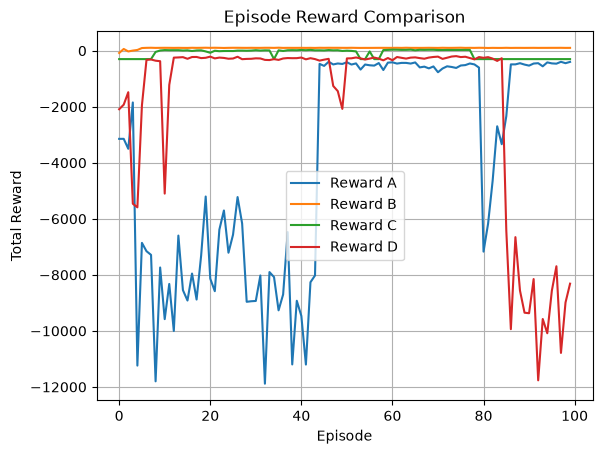

In [8]:
for reward_type in ["A", "B", "C", "D"]:
    plt.plot(results[reward_type]["episode_rewards"], label=f"Reward {reward_type}")

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Episode Reward Comparison")
plt.legend()
plt.grid()
plt.show()

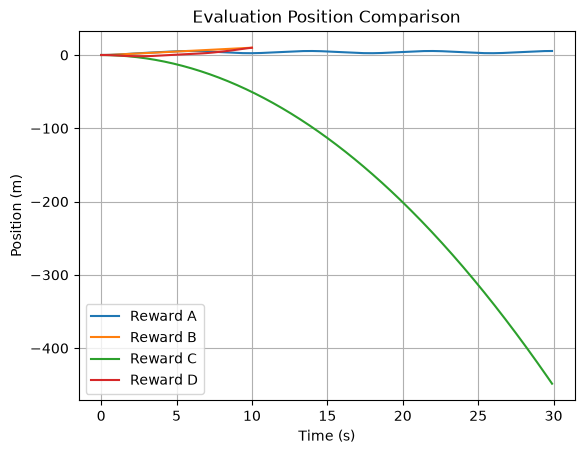

In [9]:
for reward_type in ["A", "B", "C", "D"]:
    trajectory = results[reward_type]["trajectory"]
    plt.plot(trajectory["times"], trajectory["positions"], label=f"Reward {reward_type}")

plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Evaluation Position Comparison")
plt.legend()
plt.grid()
plt.show()

In [10]:
for reward_type in ["A", "B", "C", "D"]:
    trajectory = results[reward_type]["trajectory"]
    print("Reward", reward_type)
    print("done:", trajectory["done"])
    print("final position:", trajectory["positions"][-1] if trajectory["positions"] else None)
    print("actions:", trajectory["actions"])
    print()

Reward A
done: False
final position: 5.4599999999999955
actions: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, -1, -1, -1, -1, 1, -1, 1, -1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 